In [ ]:
## ref:https://mp.weixin.qq.com/s/AJmVF1mRYQcuG73iKmkWQg

In [ ]:
# library(optparse)
# op_list <- list(
# make_option(c("-l", "--input_loom"), type = "character", default = NULL, action = "store", help = "The input of aucell loom file",metavar="rds"),
# make_option(c("-m", "--input_meta"), type = "character", default = NULL, action = "store", help = "The metadata of Seurat object",metavar="idents"),
# make_option(c("-c", "--celltype"), type = "character", default = NULL, action = "store", help = "The colname of metadata to calculate RSS",metavar="label")
# )
# parser <- OptionParser(option_list = op_list)
# opt = parse_args(parser)

In [8]:
options(warn = -1)
getwd()

library(Seurat)
library(SCopeLoomR)
library(AUCell)
library(SCENIC)
library(dplyr)
library(KernSmooth)
library(RColorBrewer)
library(plotly)
library(BiocParallel)

[1] "/data/work/02.result/others/ST_NC/02.result/05.scenic"

Attaching SeuratObject


Attaching package: ‘SCopeLoomR’


The following object is masked from ‘package:base’:

    flush



Attaching package: ‘SCENIC’


The following object is masked from ‘package:AUCell’:

    plotEmb_rgb



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


KernSmooth 2.23 loaded
Copyright M. P. Wand 1997-2009

Loading required package: ggplot2


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




In [2]:
getwd()

[1] "/data/work/02.result/others/ST_NC/01.script"

In [3]:
setwd('../02.result/05.scenic')

In [4]:
# loom <- open_loom(opt$input_loom)
loom <- open_loom('./step2.result/aucell.loom')
loom

Class: H5File
Filename: /data/work/02.result/others/ST_NC/02.result/05.scenic/step2.result/aucell.loom
Access type: H5F_ACC_RDONLY
Attributes: last_modified
Listing:
       name    obj_type  dataset.dims dataset.type_class
      attrs   H5I_GROUP          <NA>               <NA>
  col_attrs   H5I_GROUP          <NA>               <NA>
 col_graphs   H5I_GROUP          <NA>               <NA>
     layers   H5I_GROUP          <NA>               <NA>
     matrix H5I_DATASET 50000 x 10000          H5T_FLOAT
  row_attrs   H5I_GROUP          <NA>               <NA>
 row_graphs   H5I_GROUP          <NA>               <NA>

In [6]:
regulons_incidMat <- get_regulons(loom, column.attr.name="Regulons") # 提取调控元件（regulons）的矩阵 (regulons_incidMat)
regulons <- regulonsToGeneLists(regulons_incidMat)                   # 将提取到的调控元件矩阵 (regulons_incidMat) 转换为基因列表
regulonAUC <- get_regulons_AUC(loom,column.attr.name='RegulonsAUC')  # 提取每个调控元件的 AUC（曲线下面积）值(量化调控元件在细胞中的活动水平)。column.attr.name='RegulonsAUC'  AUC 列属性名
regulonAucThresholds <- get_regulon_thresholds(loom)                 # 提取调控元件的阈值，这些阈值用于区分调控元件在不同细胞中的活跃程度
close_loom(loom)

## 查看loom信息and格式

In [18]:
class(regulons_incidMat)
dim(regulons_incidMat)
head(regulons_incidMat)

[1] "matrix" "array"

[1]    15 10000

,PLEKHN1,ISG15,SAMD11,PERM1,HES4,RNF223,TTLL10,TNFRSF18,SCNN1D,TAS1R3,⋯,AC096642.2,NAV2-AS3,AC063948.1,AC079949.5,AL133313.1,AP001429.1,PCDHGC5,PRR18,AC092198.1,IGHV3-11
ELF5(+),0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERG(+),0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
FOXA1(+),0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
FOXI1(+),0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
HOXB5(+),0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
IRF6(+),0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [9]:
class(regulons)
length(regulons)
head(regulons[[1]])

[1] "list"

[1] 15

[1] "PADI2"   "PLA2G2F" "CAMK2N1" "ASAP3"   "NCMAP"   "RIMKLA"

In [16]:
regulonAUC
dim(regulonAUC@assays@data$AUC)
regulonAUC@assays@data$AUC

AUC for 15 regulons (rows) and 50000 cells (columns).

Top-left corner of the AUC matrix:
          cells
regulons   Normal_6_CELL72438_N1 Normal_2_CELL45446_N1
  ELF5(+)             0.04451852            0.16404630
  ERG(+)              0.01621818            0.02574545
  FOXA1(+)            0.03926829            0.02965854
  FOXI1(+)            0.03300000            0.05558333
  HOXB5(+)            0.01103030            0.01290909
  IRF6(+)             0.03600000            0.02950000
          cells
regulons   DPTDI_5_DSDB_22dpb_healing1__XGY_ATGTGGGACAAT_10
  ELF5(+)                                       0.045925926
  ERG(+)                                        0.002181818
  FOXA1(+)                                      0.026609756
  FOXI1(+)                                      0.003333333
  HOXB5(+)                                      0.007939394
  IRF6(+)                                       0.133250000
          cells
regulons   SPTDI_1_SSDB_7dpb2__BGI_CELL4205_N1
  ELF5(+) 

[1]    15 50000

,Normal_6_CELL72438_N1,Normal_2_CELL45446_N1,DPTDI_5_DSDB_22dpb_healing1__XGY_ATGTGGGACAAT_10,SPTDI_1_SSDB_7dpb2__BGI_CELL4205_N1,DPTDI_2_DSDB_22dpb_nonhealing1__XGY_CGAATTCCTTTC_11,SPTDI_3_SSDB_19dpb__XGY_TGCCCACCTACA_6,Normal_8_CELL13856_N2,Normal_9_CELL3831_N3,Normal_9_CELL3750_N2,Normal_9_CELL34451_N1,⋯,FTDI_4_CGATATTCGCCA_8,FTDI_3_GAATCAGAAAAA_9,Normal_8_CELL3914_N2,FTDI_4_TGAGTACATCGA_8,Normal_9_CELL12977_N3,Normal_9_CELL45825_N1,Normal_10_CELL27304_N1,Normal_9_CELL28067_N1,Normal_8_CELL27185_N1,Normal_8_CELL20991_N1
ELF5(+),0.044518519,0.164046296,0.0459259259,0.01629630,0.030194444,0.072777778,0.036018519,0.06575000,0.066148148,0.075277778,⋯,0.062388889,0.029398148,0.066814815,0.120703704,0.08251852,0.049037037,0.035379630,0.078166667,0.031212963,0.082287037
ERG(+),0.016218182,0.025745455,0.0021818182,0.02272727,0.003454545,0.009272727,0.042145455,0.04487273,0.044145455,0.009309091,⋯,0.014400000,0.020400000,0.011781818,0.004436364,0.01876364,0.038872727,0.031600000,0.016109091,0.254254545,0.022545455
FOXA1(+),0.039268293,0.029658537,0.0266097561,0.02448780,0.014560976,0.022243902,0.017780488,0.01180488,0.013951220,0.022146341,⋯,0.017512195,0.034829268,0.022073171,0.016073171,0.02402439,0.016000000,0.039609756,0.022195122,0.021682927,0.021487805
FOXI1(+),0.033000000,0.055583333,0.0033333333,0.00000000,0.005583333,0.024666667,0.051416667,0.03000000,0.000000000,0.000000000,⋯,0.007000000,0.000000000,0.065500000,0.013333333,0.02275000,0.026333333,0.024500000,0.000000000,0.000000000,0.030000000
HOXB5(+),0.011030303,0.012909091,0.0079393939,0.07242424,0.032606061,0.001030303,0.023939394,0.02806061,0.007151515,0.005333333,⋯,0.000000000,0.004484848,0.019757576,0.000000000,0.01763636,0.031333333,0.032545455,0.033151515,0.057575758,0.022121212
IRF6(+),0.036000000,0.029500000,0.1332500000,0.00000000,0.259833333,0.227500000,0.095416667,0.09816667,0.059833333,0.149000000,⋯,0.199583333,0.197166667,0.229916667,0.095916667,0.10783333,0.069000000,0.064916667,0.180500000,0.026000000,0.140333333
IRF8(+),0.002071429,0.000000000,0.0002857143,0.00000000,0.049642857,0.010750000,0.000000000,0.00000000,0.000000000,0.000000000,⋯,0.003750000,0.000000000,0.002642857,0.022214286,0.00000000,0.000000000,0.002321429,0.001964286,0.014321429,0.000000000
NR2F2(+),0.014444444,0.003925926,0.0120000000,0.27074074,0.015777778,0.019851852,0.009111111,0.00362963,0.061407407,0.007407407,⋯,0.000000000,0.006370370,0.006962963,0.034000000,0.01800000,0.010148148,0.040148148,0.014370370,0.086148148,0.004888889
POU5F1B(+),0.000000000,0.011034483,0.0324827586,0.10420690,0.015034483,0.032344828,0.045448276,0.05227586,0.035241379,0.071448276,⋯,0.007586207,0.031241379,0.023655172,0.007931034,0.04986207,0.033379310,0.023793103,0.030896552,0.082137931,0.011517241
RAX(+),0.008750000,0.001650000,0.0000000000,0.03905000,0.007750000,0.000000000,0.049200000,0.01060000,0.005550000,0.004050000,⋯,0.013000000,0.003350000,0.007100000,0.004150000,0.02780000,0.005900000,0.008800000,0.008700000,0.008400000,0.002350000


In [17]:
head(regulonAucThresholds,10)

0.113314466987879   0.10413203984238 0.0757264045116831  0.118319216647902 
         "ELF5(+)"           "ERG(+)"         "FOXA1(+)"         "FOXI1(+)" 
0.0488466806317276 0.0606569314222265 0.0672490190981208  0.131456375602353 
        "HOXB5(+)"          "IRF6(+)"          "IRF8(+)"         "NR2F2(+)" 
 0.101431496347754 0.0395729171823555 
      "POU5F1B(+)"           "RAX(+)"

## 计算RSS
#### RSS (Regulon Specificity Score) 是一个用于评估每个调控因子（转录因子）在不同细胞类型或状态中的特异性表达的指标。
#### RSS 越高 → 这个 regulon 越特异于这个 cluster
#### RSS 值能够帮助识别在特定细胞类型中起关键调控作用的转录因子。
#### SCENIC提供了一个 plotRSS函数能根据 RSS得分筛选细胞类型特异的 regulons，而且可以对 RSS得 分进行可视化。注意 RSS分值和活性值不能搞混，RSS分值衡量的是regulons对某种细胞类型的特异性。

In [47]:
meta = read.csv('/data/work/02.result/others/ST_NC/02.result/meta_anno_0818.csv',row.names = 1)
head(meta,3)


cellinfo <- meta[,c('celltype_0818',"nFeature_RNA","nCount_RNA")]
colnames(cellinfo)=c('celltype', 'nGene' ,'nUMI')
head(cellinfo)

cellTypes <-  as.data.frame(subset(cellinfo,select = 'celltype'))
head(cellTypes)

selectedResolution <- "celltype"

,celltype
,<chr>
Normal_1_CELL1_N5,KC_Spinosum
Normal_1_CELL2_N3,KC_Spinosum
Normal_1_CELL6_N3,KC_Basal
Normal_1_CELL11_N3,KC_Spinosum
Normal_1_CELL13_N4,KC_Basal
Normal_1_CELL14_N6,KC_Basal


In [28]:
# 计算 RSS（Regulon Specificity Score）
sub_regulonAUC <- regulonAUC
rss <- calcRSS(AUC=getAUC(sub_regulonAUC),  # 从 AUCell 结果对象中取出 AUC 数值矩阵（行=regulon，列=cell）。
               cellAnnotation = cellTypes[colnames(sub_regulonAUC),selectedResolution]) # 按细胞 ID 在 cellTypes 表中按行对齐取出某一列注释（selectedResolution 是列名，比如 "celltype"）。得到一个 长度=细胞数 的注释向量
head(rss)

rss = na.omit(rss) # 去掉含有 NA 的行（对矩阵/数据框是整行去除；若是向量则去掉 NA 条目）

# try({ ... })：吞错。即使里面报错，脚本也不会中断
try({ 
rssPlot <- plotRSS(rss) # rssPlot 是 一个 列表/对象，通常包含 (1)ggplot2 图对象 (2) df (3) rowOrder
save(rss, regulonAUC, rssPlot,regulons,file='./regulon_RSS.Rdata')  # load('regulon_RSS.Rdata')
})


,KC_Spinosum,KC_Basal,Fibroblast,KC_Granulosum,Endothelial Cell,SAC,Lymphocyte,Macrophage,Melanocyte,Neurocyte
ELF5(+),0.26712758,0.4406697,0.06022126,0.09577338,0.04081414,0.05707961,0.02870771,0.02889090,0.011984545,0.003469400
ERG(+),0.11204238,0.2820015,0.11578733,0.01586861,0.36565211,0.04258181,0.05084477,0.03661718,0.010035039,0.007314156
FOXA1(+),0.15179810,0.4012287,0.13093893,0.02599456,0.10373639,0.13641492,0.05228268,0.05642209,0.012686203,0.007084668
FOXI1(+),0.15991107,0.3788843,0.12466619,0.02655840,0.07818785,0.11892329,0.05359618,0.05478861,0.013515258,0.004926467
HOXB5(+),0.09558729,0.2501588,0.30080147,0.01247441,0.19921564,0.01780920,0.05010781,0.05333406,0.019012859,0.008119923
IRF6(+),0.19063408,0.5631293,0.04171968,0.03993845,0.03723911,0.04167479,0.01509200,0.01864762,0.008282833,0.001642421


In [39]:
# identical(colnames(sub_regulonAUC), colnames(obj)) #确认是否一致
# mached_AUC <- regulonAUC[,match(colnames(obj),colnames(regulonAUC))]
# dim(mached_AUC)

[1]    16 88991

In [1]:
setwd('../02.result/05.scenic')
load('regulon_RSS.Rdata')

In [4]:
dim(regulonAUC)

[1]    15 50000

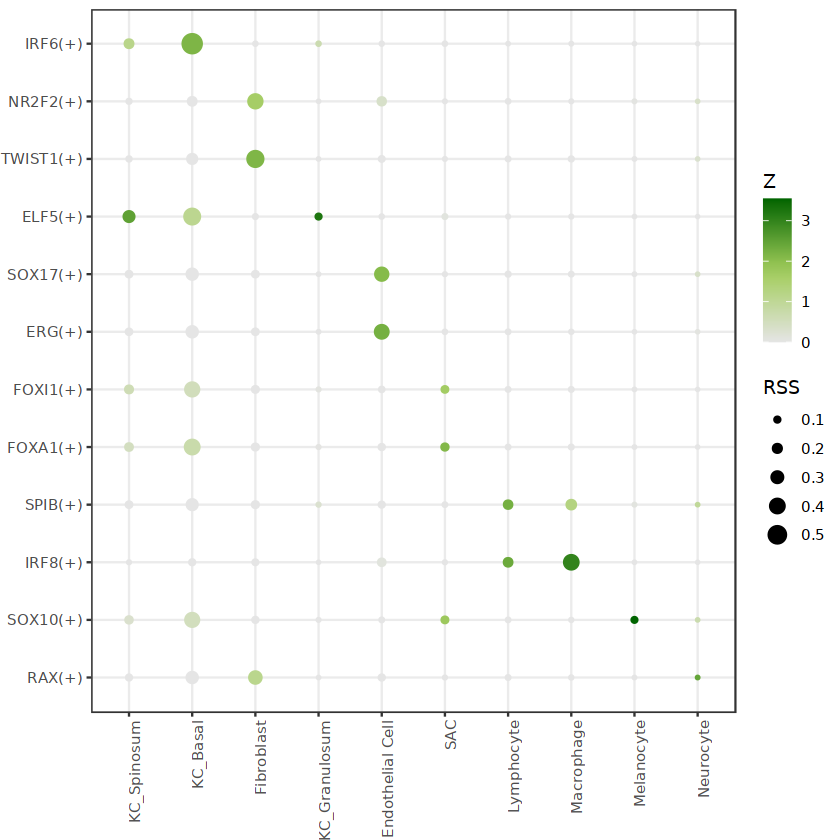

In [7]:
rssPlot$plot

In [10]:
ggsave('rssPlot.pdf', rssPlot$plot, width = 6, height = 8, bg = "white")

## plots

In [48]:
colors = c("#77587D", "#3C8A9C", "#4AA857", "#727E76", "#A3568E", "#DB822A", "#F38C49", "#F781BF", "#D292C7", "#B68BA3", 
           "#A85E3C", "#7C8386", "#4D9FD6", "#2E4F90", "#1F5875", "#1B9E77", "#79C682", "#BED667", "#DCC211", "#EFAC4C", 
           "#F88B97", "#EC458D", "#C61A6E", "#900241", "#36809B", "#29CDD5", "#91CDE0", "#BA6FA1", "#BF1969", "#7A3F91", 
           "#6F7093", "#8CA77B", "#34693E", "#376A14", "#C2C903", "#C8DD34", "#AEDC74", "#96D5AF", "#91BDB5", "#999999")

color <- colors[1:length(unique(cellinfo$celltype))]
names(color) <- unique(cellinfo$celltype)
color

KC_Spinosum         KC_Basal    KC_Granulosum       Melanocyte 
       "#77587D"        "#3C8A9C"        "#4AA857"        "#727E76" 
Endothelial Cell       Lymphocyte              SAC       Fibroblast 
       "#A3568E"        "#DB822A"        "#F38C49"        "#F781BF" 
      Macrophage        Neurocyte 
       "#D292C7"        "#B68BA3"

### heatmap

In [72]:
auc <- as.matrix(regulonAUC@assays@data$AUC)

# 创建注释数据框
annotation <- data.frame(celltype = cellinfo$celltype, row.names = rownames(cellinfo))
annotation <- annotation[colnames(auc), , drop = FALSE]

# 设定颜色
color <- colors[1:length(unique(cellinfo$celltype))]
names(color) <- unique(cellinfo$celltype)
color

#auc <- auc[, rownames(annotation)] # 取 cell 交集
head(auc)

# 所有细胞的活性值
## 归一化数据
torange <- c(-2, 2)
auc <- scales::rescale(auc, to = torange)

pdf('all_regulon_activity_in_allcells.pdf', width = 10, height = ceiling(length(unique(names(regulons))) * 0.2))

    pheatmap(auc, 
             annotation_col = annotation,  # 添加列注释
             annotation_colors = list(group1 = color),  # 设置注释颜色
             scale = 'none',  # 不对数据进行额外缩放
             show_rownames = TRUE,  # 显示行名
             show_colnames = FALSE,  # 不显示列名
             cluster_cols = FALSE,  # 不对列进行聚类
             use_raster = TRUE
    )

dev.off()

KC_Spinosum         KC_Basal    KC_Granulosum       Melanocyte 
       "#77587D"        "#3C8A9C"        "#4AA857"        "#727E76" 
Endothelial Cell       Lymphocyte              SAC       Fibroblast 
       "#A3568E"        "#DB822A"        "#F38C49"        "#F781BF" 
      Macrophage        Neurocyte 
       "#D292C7"        "#B68BA3"

,Normal_6_CELL72438_N1,Normal_2_CELL45446_N1,DPTDI_5_DSDB_22dpb_healing1__XGY_ATGTGGGACAAT_10,SPTDI_1_SSDB_7dpb2__BGI_CELL4205_N1,DPTDI_2_DSDB_22dpb_nonhealing1__XGY_CGAATTCCTTTC_11,SPTDI_3_SSDB_19dpb__XGY_TGCCCACCTACA_6,Normal_8_CELL13856_N2,Normal_9_CELL3831_N3,Normal_9_CELL3750_N2,Normal_9_CELL34451_N1,⋯,FTDI_4_CGATATTCGCCA_8,FTDI_3_GAATCAGAAAAA_9,Normal_8_CELL3914_N2,FTDI_4_TGAGTACATCGA_8,Normal_9_CELL12977_N3,Normal_9_CELL45825_N1,Normal_10_CELL27304_N1,Normal_9_CELL28067_N1,Normal_8_CELL27185_N1,Normal_8_CELL20991_N1
ELF5(+),0.04451852,0.16404630,0.045925926,0.01629630,0.030194444,0.072777778,0.03601852,0.06575000,0.066148148,0.075277778,⋯,0.06238889,0.029398148,0.06681481,0.120703704,0.08251852,0.04903704,0.03537963,0.07816667,0.03121296,0.08228704
ERG(+),0.01621818,0.02574545,0.002181818,0.02272727,0.003454545,0.009272727,0.04214545,0.04487273,0.044145455,0.009309091,⋯,0.01440000,0.020400000,0.01178182,0.004436364,0.01876364,0.03887273,0.03160000,0.01610909,0.25425455,0.02254545
FOXA1(+),0.03926829,0.02965854,0.026609756,0.02448780,0.014560976,0.022243902,0.01778049,0.01180488,0.013951220,0.022146341,⋯,0.01751220,0.034829268,0.02207317,0.016073171,0.02402439,0.01600000,0.03960976,0.02219512,0.02168293,0.02148780
FOXI1(+),0.03300000,0.05558333,0.003333333,0.00000000,0.005583333,0.024666667,0.05141667,0.03000000,0.000000000,0.000000000,⋯,0.00700000,0.000000000,0.06550000,0.013333333,0.02275000,0.02633333,0.02450000,0.00000000,0.00000000,0.03000000
HOXB5(+),0.01103030,0.01290909,0.007939394,0.07242424,0.032606061,0.001030303,0.02393939,0.02806061,0.007151515,0.005333333,⋯,0.00000000,0.004484848,0.01975758,0.000000000,0.01763636,0.03133333,0.03254545,0.03315152,0.05757576,0.02212121
IRF6(+),0.03600000,0.02950000,0.133250000,0.00000000,0.259833333,0.227500000,0.09541667,0.09816667,0.059833333,0.149000000,⋯,0.19958333,0.197166667,0.22991667,0.095916667,0.10783333,0.06900000,0.06491667,0.18050000,0.02600000,0.14033333


'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

### DotPlot

In [78]:
obj <- readRDS('./anno_0818_5w_1wHVG.rds')
obj

head(obj,3)

,Time_category,celltype_0818,obs_names,orig.ident,sample
,<fct>,<fct>,<chr>,<fct>,<fct>
Normal_6_CELL72438_N1,Normal,KC_Spinosum,Normal_6_CELL72438_N1,Normal_6,Normal_6
Normal_2_CELL45446_N1,Normal,KC_Spinosum,Normal_2_CELL45446_N1,Normal_2,Normal_2
DPTDI_5_DSDB_22dpb_healing1__XGY_ATGTGGGACAAT_10,15-28dpb,KC_Basal,DPTDI_5_DSDB_22dpb_healing1__XGY_ATGTGGGACAAT_10,DSDB,DPTDI_5


In [79]:
obj@meta.data = cbind(obj@meta.data, sub_regulonAUC@assays@data@listData$AUC %>% t())
head(obj@meta.data,3)

,Time_category,celltype_0818,obs_names,orig.ident,sample,ELF5(+),ERG(+),FOXA1(+),FOXI1(+),HOXB5(+),IRF6(+),IRF8(+),NR2F2(+),POU5F1B(+),RAX(+),SOX10(+),SOX17(+),SPI1(+),SPIB(+),TWIST1(+)
,<fct>,<fct>,<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Normal_6_CELL72438_N1,Normal,KC_Spinosum,Normal_6_CELL72438_N1,Normal_6,Normal_6,0.04451852,0.016218182,0.03926829,0.033000000,0.011030303,0.03600,0.0020714286,0.014444444,0.00000000,0.00875,0.008370370,0.03778571,0.03250337,0.010328125,0.013936
Normal_2_CELL45446_N1,Normal,KC_Spinosum,Normal_2_CELL45446_N1,Normal_2,Normal_2,0.16404630,0.025745455,0.02965854,0.055583333,0.012909091,0.02950,0.0000000000,0.003925926,0.01103448,0.00165,0.012074074,0.00525000,0.02399101,0.023140625,0.008144
DPTDI_5_DSDB_22dpb_healing1__XGY_ATGTGGGACAAT_10,15-28dpb,KC_Basal,DPTDI_5_DSDB_22dpb_healing1__XGY_ATGTGGGACAAT_10,DSDB,DPTDI_5,0.04592593,0.002181818,0.02660976,0.003333333,0.007939394,0.13325,0.0002857143,0.012000000,0.03248276,0.00000,0.004962963,0.00000000,0.04209888,0.003703125,0.005984


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


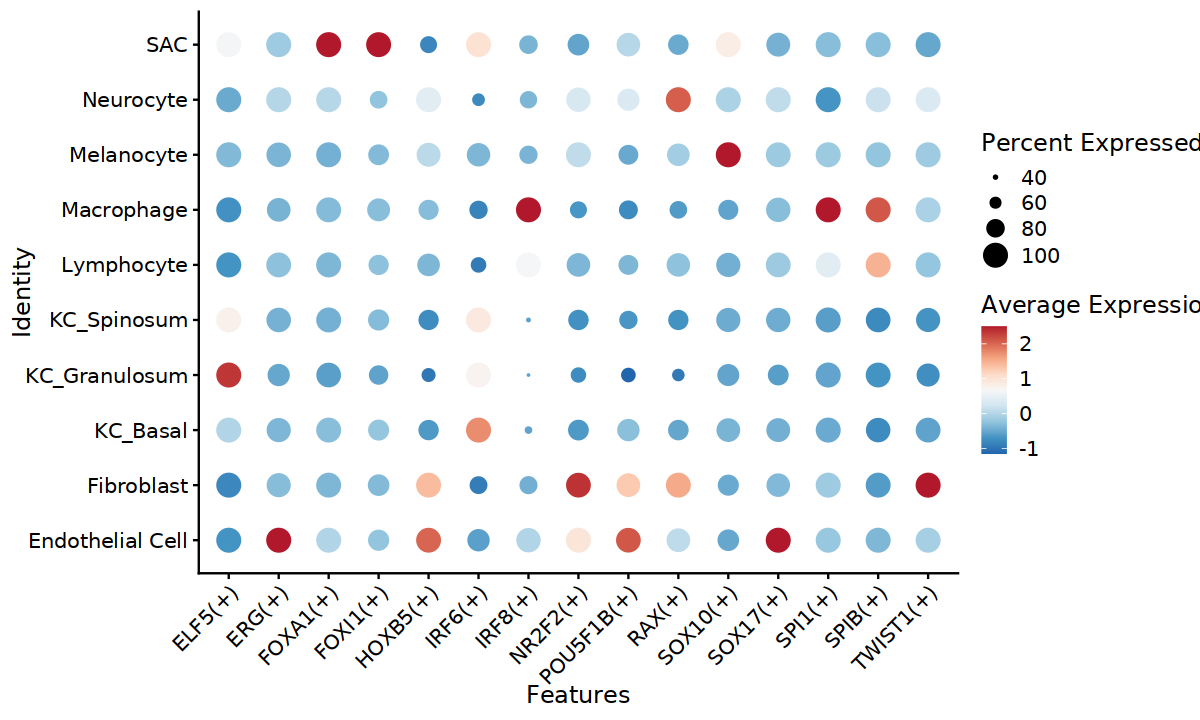

In [89]:
options(repr.plot.width = 10, repr.plot.height = 6)

Idents(obj) <- 'celltype_0818' # 记得改 Idents 如果 Idents 跟 scale_y_discrete不同，画不出来
p1 = DotPlot(obj, features = unique(row.names(sub_regulonAUC)) , cluster.idents = FALSE ) + 
             RotatedAxis() + 
             scale_color_gradientn(colours  = brewer.pal(n = 9, name = "RdBu") %>% rev()) + 
             scale_y_discrete(limits=sort(unique(obj$celltype_0818)),position = "left")
p1

ggsave('regulons_activity_in_dotplot.png', p1, width = 10, height = 6, bg = "white")

### VlnPlot & Ridgeplot

In [ ]:
regulonsToPlot <- unique(row.names(sub_regulonAUC))
length(regulonsToPlot)
regulonsToPlot

[1] 15

[1] "ELF5(+)"    "ERG(+)"     "FOXA1(+)"   "FOXI1(+)"   "HOXB5(+)"  
 [6] "IRF6(+)"    "IRF8(+)"    "NR2F2(+)"   "POU5F1B(+)" "RAX(+)"    
[11] "SOX10(+)"   "SOX17(+)"   "SPI1(+)"    "SPIB(+)"    "TWIST1(+)"

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Picking joint bandwidth of 0.00414

Picking joint bandwidth of 0.00364

Picking joint bandwidth of 0.00327

Picking joint bandwidth of 0.00615

Picking joint bandwidth of 0.0037

Picking joint bandwidth of 0.00767

Picking joint bandwidth of 0.00323

Picking joint bandwidth of 0.00646

Picking joint bandwidth of 0.00529

Picking joint bandwidth of 0.00299

Picking joint bandwidth of 0.00414

Picking joint bandwidth of 0.00362

Picking joint bandwidth of 0.00241

Picking joint bandwidth of 0.00241

Picking joint bandwidth of 0.00317

Picking joint bandwidth of 0.00414

Picking joint bandwidth of 0.00364

Picking joint bandwidth of 0.00327

Picking joint bandwidth of 0.00615

Picking joint bandwidth of 0.0037

Picking joint bandwidth of 0.00767

Picking joint bandwidth of 0.00323

Picking joint bandwidth of 0.00646

Picking joint bandwidth of 0.00529

Picking joint bandwidth of 0.00299

Pic

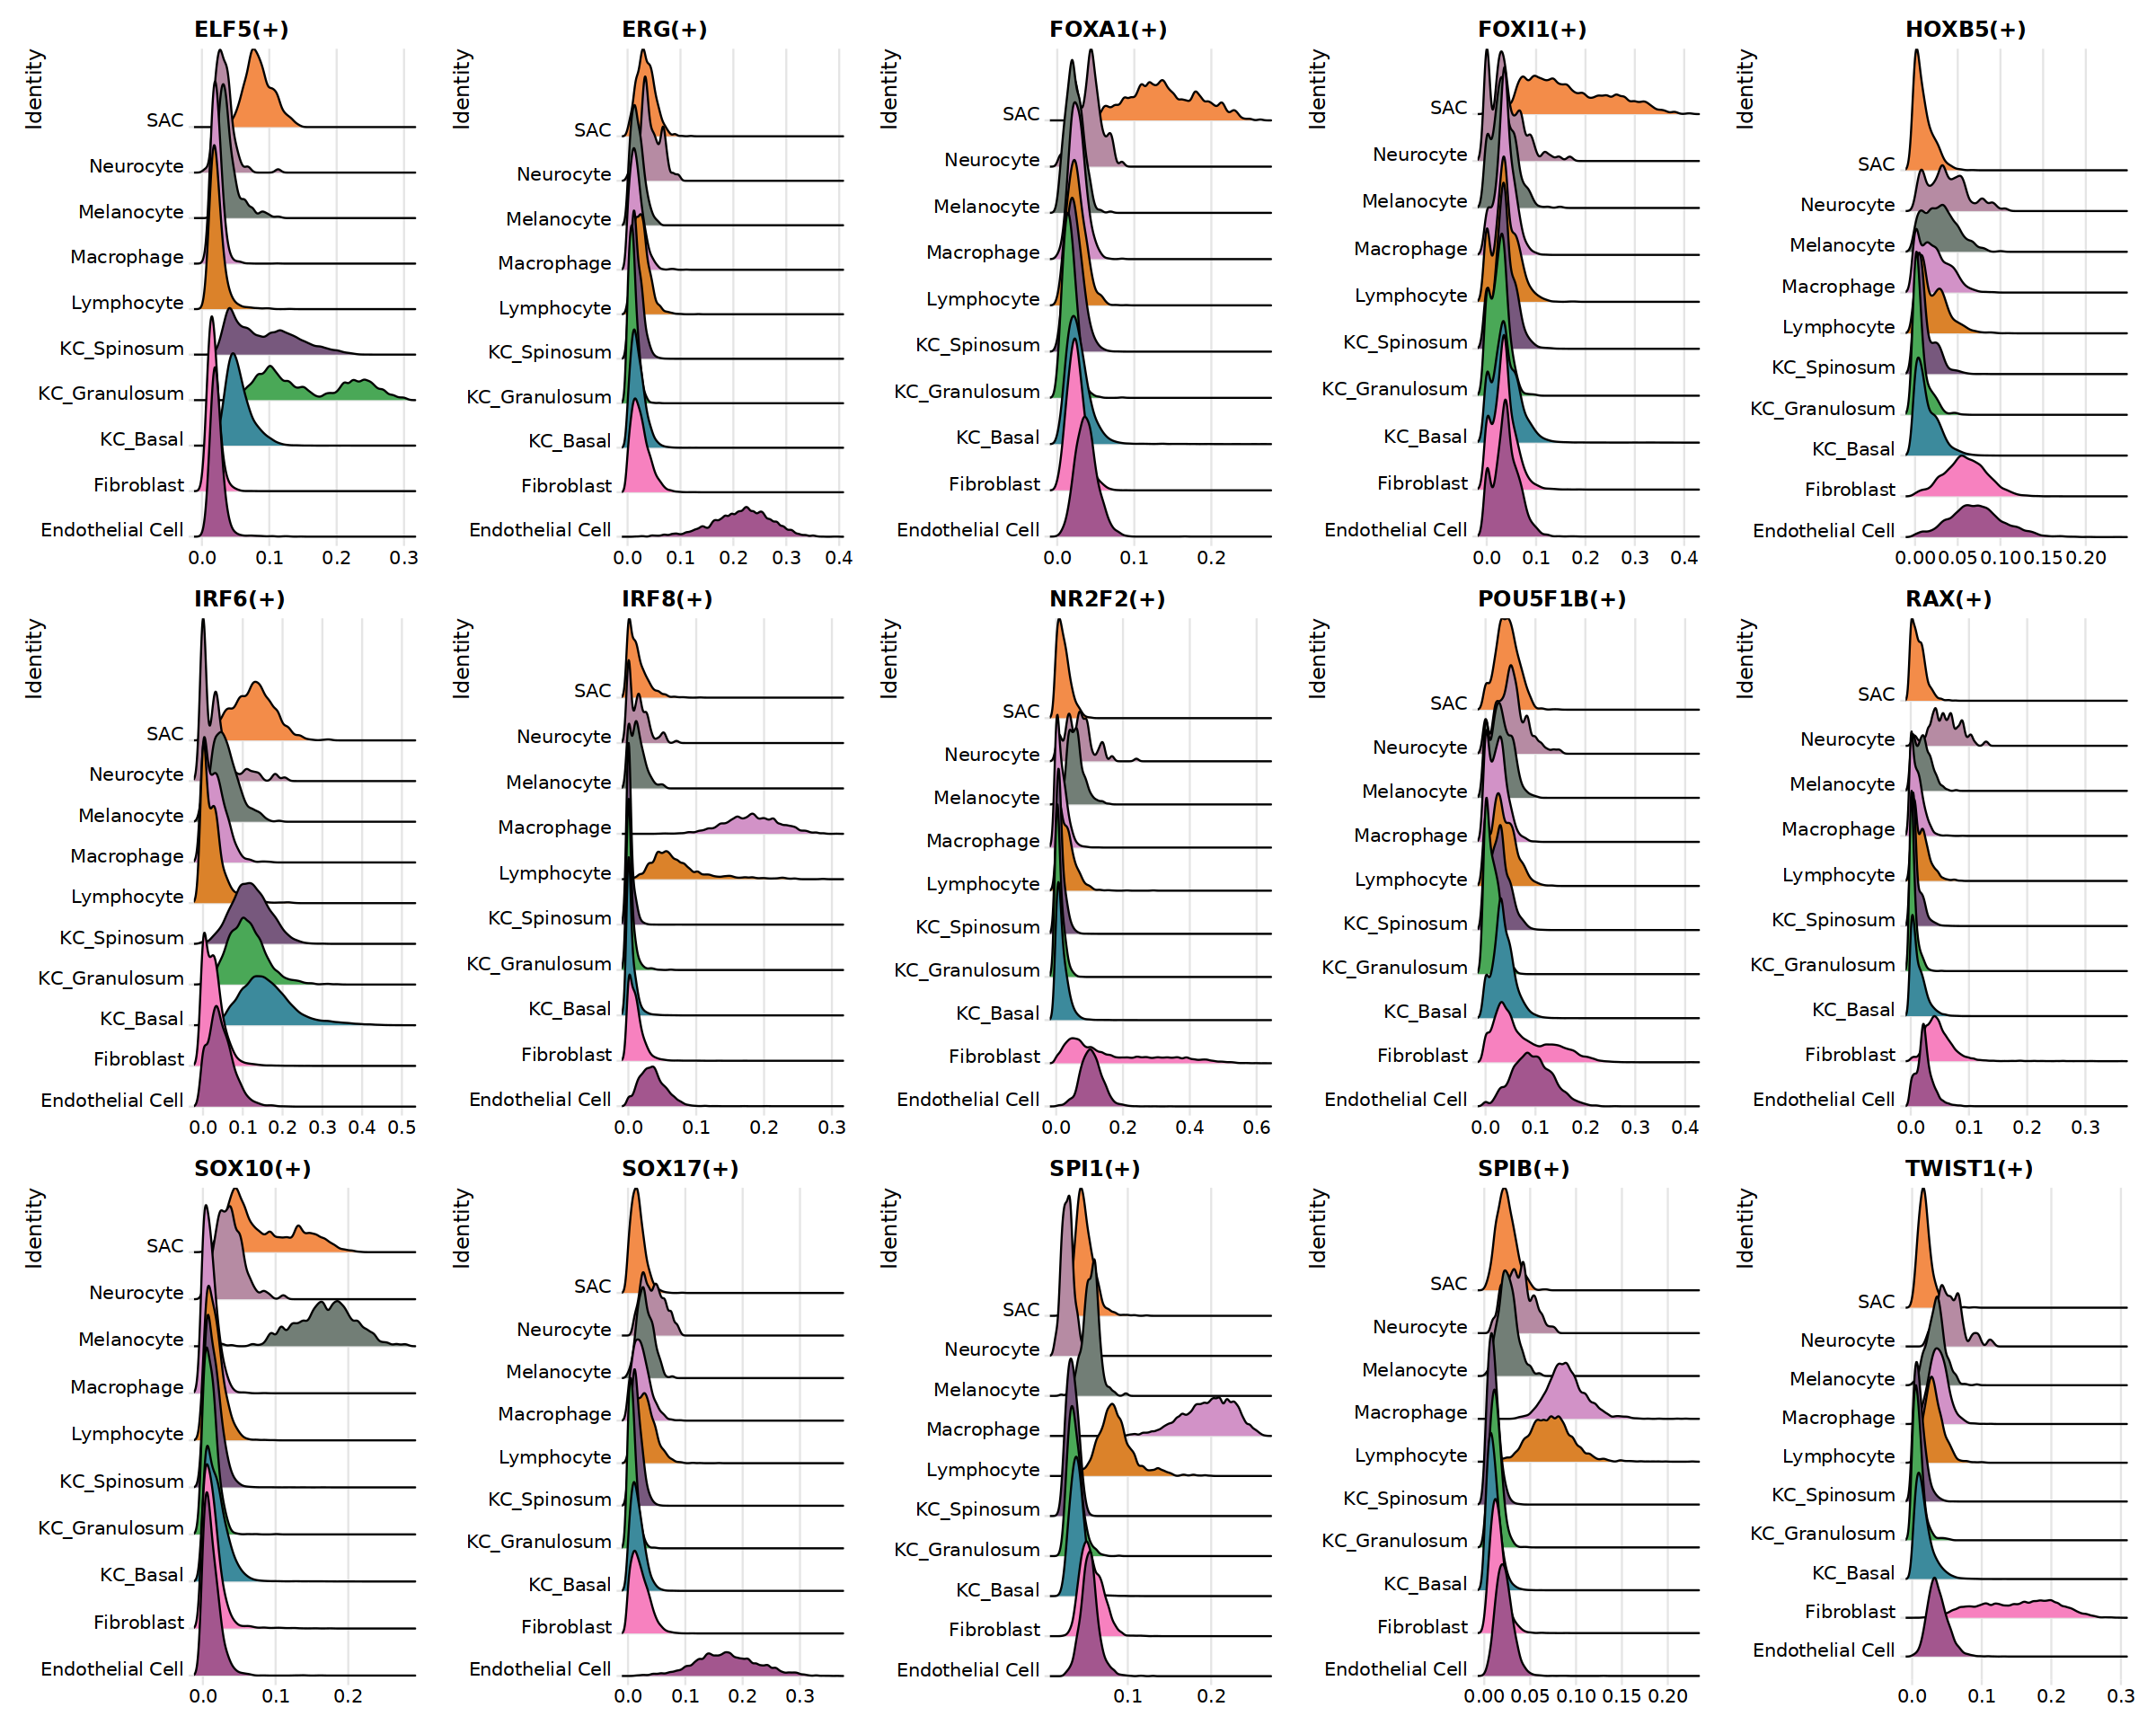

In [110]:
options(repr.plot.width = 20, repr.plot.height = 16)
p2 = RidgePlot(obj, features = regulonsToPlot , ncol = 5, cols = color) + scale_y_discrete(limits=sort(unique(obj$celltype_0818)),position = "left")
p2
ggsave('regulons_activity_in_RidgePlot.png', p2, width = 20, height = 16, bg = "white")


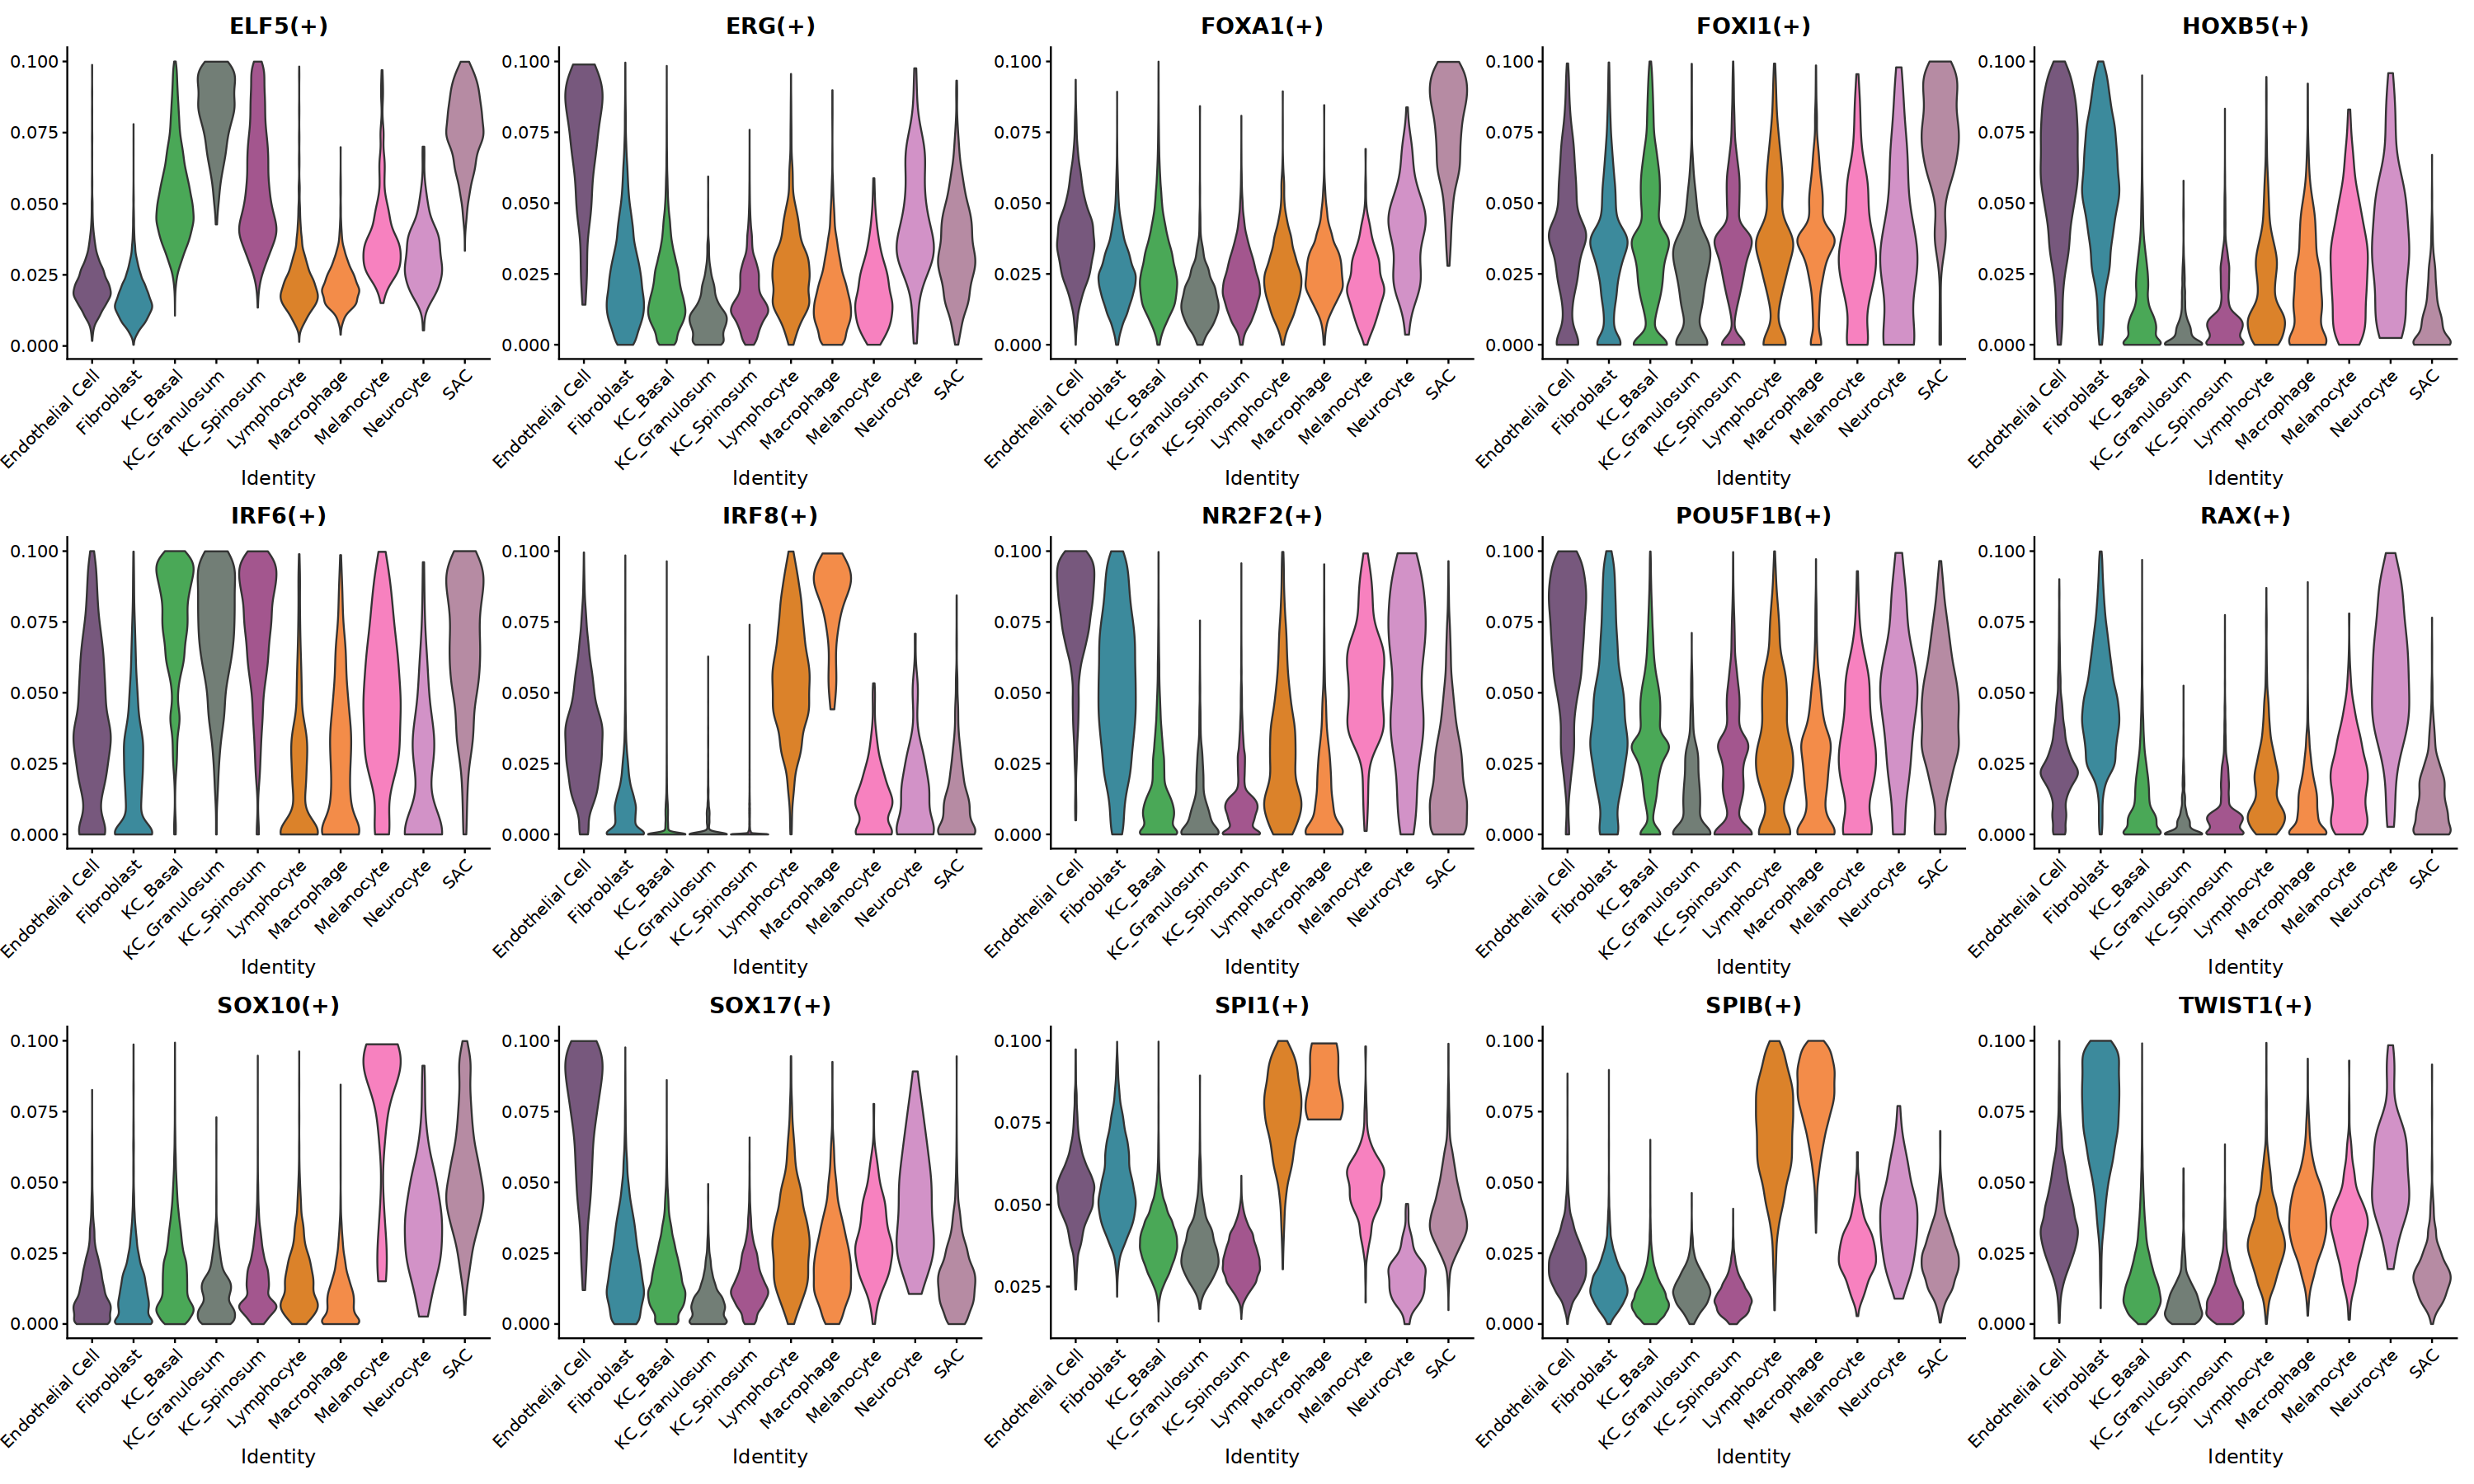

In [111]:
options(repr.plot.width = 25, repr.plot.height = 15)
p3 = VlnPlot(obj, features = regulonsToPlot, pt.size = 0, ncol = 5, cols = colors, y.max = 0.1)
p3
ggsave('regulons_activity_in_VlnPlot.png', p3, width = 25, height = 15, bg = "white")

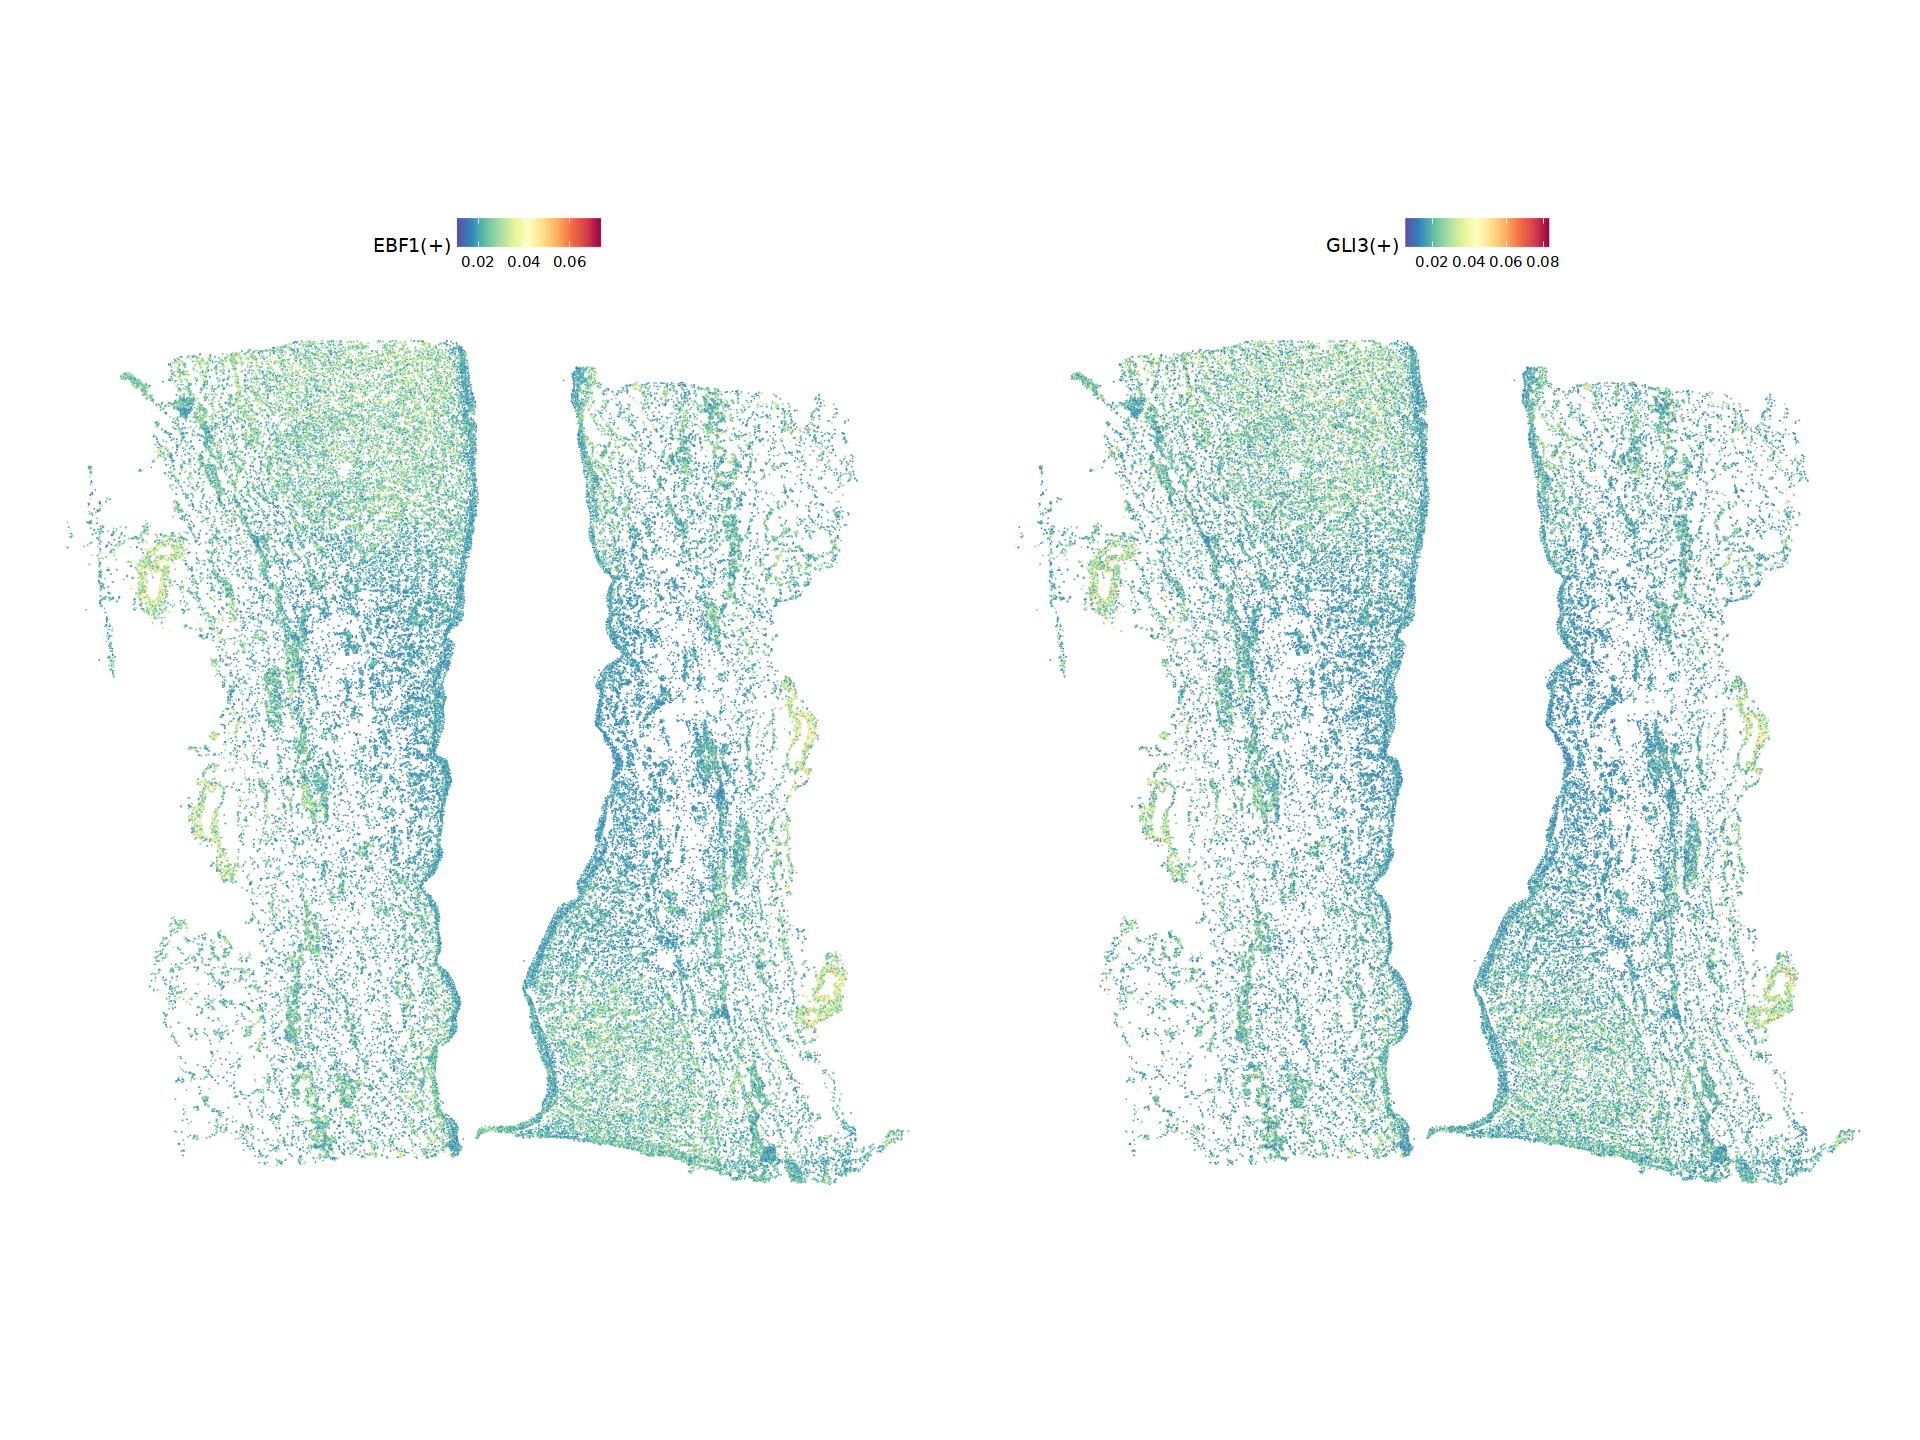

In [154]:
options(repr.plot.width = 16, repr.plot.height = 12)
p <- SpatialFeaturePlot(obj, features = regulonsToPlot, stroke = NA, pt.size.factor=20, alpha=1)
p

### GRN

In [18]:
library(tidygraph)
library(ggraph)
library(scales)


Attaching package: ‘tidygraph’


The following object is masked from ‘package:stats’:

    filter




In [12]:
getwd()

[1] "/data/work/02.result/others/ST_NC/02.result/05.scenic"

In [16]:
# 定义要绘图的 regulons
regulonsToPlot <- unique(row.names(regulonAUC))
length(regulonsToPlot)
regulonsToPlot

[1] 15

[1] "ELF5(+)"    "ERG(+)"     "FOXA1(+)"   "FOXI1(+)"   "HOXB5(+)"  
 [6] "IRF6(+)"    "IRF8(+)"    "NR2F2(+)"   "POU5F1B(+)" "RAX(+)"    
[11] "SOX10(+)"   "SOX17(+)"   "SPI1(+)"    "SPIB(+)"    "TWIST1(+)"

In [26]:
# 定义要绘图的 regulons
regulonsToPlot <- unique(row.names(regulonAUC))
length(regulonsToPlot)
regulonsToPlot

# regulonsToPlot 已经有了，这里先清理掉 "(+)"
inregulons <- gsub("\\(\\+\\)", "", regulonsToPlot)
inregulons

# 读取 GRN
grn <- read.table("./step2.result/grn.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

# 只保留感兴趣的 TF
grn <- grn[grn$TF %in% inregulons, ]
head(grn)

# 设置每个 TF 的 target 数量上限
ntop <- 30   # 可改，比如每个 TF 取前 30 个

# 循环画图，每个 TF 单独一个 PDF
for (tf in unique(grn$TF)) {
  tmp <- subset(grn, TF == tf)
  
  # 取前 ntop 个 target（按 importance 排序）
  if (nrow(tmp) > ntop) {
    tmp <- tmp[order(tmp$importance, decreasing = TRUE), ]
    tmp <- tmp[1:ntop, ]
  }
  
  # 节点表
  node <- data.frame(node = tmp$target, node.size = 1.5, node.colour = "black")
  df1   <- data.frame(node = tf, node.size = 2, node.colour = "#FFDA00")  # TF 节点
  node <- rbind(df1, node)
  
  # 边表
  edge2 <- tmp
  colnames(edge2) <- c("from", "to", "edge.width")
  edge2$edge.colour <- "#1B9E77"
  edge2$edge.width  <- rescale(edge2$edge.width, to = c(0.1, 1)) # importance rescale
  
  # 构建网络
  graph_data <- tbl_graph(nodes = node, edges = edge2, directed = TRUE)
  
  # 画图
  p1 <- ggraph(graph = graph_data, layout = "stress", circular = TRUE) + 
    geom_edge_arc(aes(edge_colour = edge.colour, edge_width = edge.width)) +
    scale_edge_width_continuous(range = c(1, 0.2)) +
    geom_node_point(aes(colour = node.colour, size = node.size)) +
    geom_node_label(aes(label = node, colour = node.colour), size = 3.5, repel = TRUE) +
    scale_color_manual(values = c("#FFDA00", "black")) +
    scale_edge_color_manual(values = c("#1B9E77")) +
    theme_void() +
    ggtitle(paste0("Regulon: ", tf)) +
    theme(plot.margin = margin(2, 2, 2, 2, unit = "cm")  # 上右下左边距
      )
  
  # 保存到 PDF
  pdf(paste0('./GRN/',tf, "_regulon_netplot.pdf"), width = 10, height = 10)
  print(p1)
  dev.off()
}


[1] "ELF5"    "ERG"     "FOXA1"   "FOXI1"   "HOXB5"   "IRF6"    "IRF8"   
 [8] "NR2F2"   "POU5F1B" "RAX"     "SOX10"   "SOX17"   "SPI1"    "SPIB"   
[15] "TWIST1"

,TF,target,importance
,<chr>,<chr>,<dbl>
60,SPI1,SERPINA1,14.91300
64,ERG,AP001407.1,14.55744
108,SPI1,IGSF6,12.61480
170,SPI1,CSF1R,11.44768
215,SPI1,SCIMP,10.74879
222,SPI1,MS4A6A,10.67161


## 基于 RSS 和 rssPlot 作图

In [131]:
# Topic TF in RSS (rssPlot$df$Topic)

TF = rss[unique(rssPlot$df$Topic),]
head(TF)

pdf('plotRSS_in_celltype.pdf', width = 8, height = 5)
    pheatmap(TF,scale='row',show_rownames = T, main='plotRSS unique regulons')
dev.off()

,KC_Spinosum,KC_Basal,Fibroblast,KC_Granulosum,Endothelial Cell,SAC,Lymphocyte,Macrophage,Melanocyte,Neurocyte
POU5F1B(+),0.11861787,0.36318344,0.21107106,0.014952309,0.15749456,0.04048212,0.04778149,0.03562512,0.011848738,0.006430759
IRF8(+),0.02761747,0.09964665,0.09251738,0.007984886,0.14894439,0.03013336,0.18621096,0.39614519,0.012431647,0.004652068
HOXB5(+),0.09558729,0.25015878,0.30080147,0.012474414,0.19921564,0.01780920,0.05010781,0.05333406,0.019012859,0.008119923
IRF6(+),0.19063408,0.56312933,0.04171968,0.039938447,0.03723911,0.04167479,0.01509200,0.01864762,0.008282833,0.001642421
SOX17(+),0.11579478,0.27928397,0.11684698,0.014441046,0.34737724,0.02693044,0.06477420,0.05286144,0.017479831,0.008244763
FOXA1(+),0.15179810,0.40122868,0.13093893,0.025994556,0.10373639,0.13641492,0.05228268,0.05642209,0.012686203,0.007084668


pdf 
  2

In [120]:
# all TF in RSS
pdf('all_RSS_in_celltype.pdf',width = 10, height = 10)
    pheatmap(rss,scale='row',show_rownames = T,main='all regulons RSS')
dev.off()

pdf 
  2